# Entrenamiento Modelo S5


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from sklearn.model_selection import train_test_split
import datetime

In [ ]:
def load_videos_from_folder_in_grayscale(folder, img_size=(240, 240), max_frames=30):
    """
    Loads videos from a folder and converts them to grayscale.

    Args:
        folder (str): Path to the folder containing 'Con_humo' and 'Sin_humo' subfolders.
        img_size (tuple): Size to resize each frame to (height, width).
        max_frames (int): Maximum number of frames to load per video.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: Array of videos with shape (n_samples, max_frames, height, width, 1).
            - np.ndarray: Array of labels (0 for 'Sin_humo', 1 for 'Con_humo').
    """
    videos = []
    labels = []
    for category in ["Con_humo", "Sin_humo"]:
        label = 0 if category == "Sin_humo" else 1
        category_folder = os.path.join(folder, category)
        for filename in os.listdir(category_folder):
            video_path = os.path.join(category_folder, filename)
            cap = cv2.VideoCapture(video_path)
            frames = []
            frame_count = 0
            while frame_count < max_frames:
                ret, frame = cap.read()
                if not ret:
                    break

                gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                gray_frame = cv2.resize(gray_frame, img_size)
                frames.append(gray_frame)
                frame_count += 1
            cap.release()
            if len(frames) < max_frames:
                frames += [np.zeros_like(frames[0])] * (max_frames - len(frames))
            video = np.array(frames)
            video = np.expand_dims(video, axis=-1)
            videos.append(video)
            labels.append(label)
    return np.array(videos), np.array(labels)


In [ ]:
dataset_path = '/content/drive/MyDrive/Dataser_protector de árboles/Dataset_aug_div/'


train_videos, train_labels = load_videos_from_folder_in_grayscale(os.path.join(dataset_path, 'train'))
valid_videos, valid_labels = load_videos_from_folder_in_grayscale(os.path.join(dataset_path, 'val'))
test_videos, test_labels = load_videos_from_folder_in_grayscale(os.path.join(dataset_path, 'test'))

print(f'Train videos: {train_videos.shape}, Train labels: {train_labels.shape}')
print(f'Validation videos: {valid_videos.shape}, Validation labels: {valid_labels.shape}')
print(f'Test videos: {test_videos.shape}, Test labels: {test_labels.shape}')


Train videos: (2800, 30, 240, 240, 1), Train labels: (2800,)
Validation videos: (800, 30, 240, 240, 1), Validation labels: (800,)
Test videos: (400, 30, 240, 240, 1), Test labels: (400,)


In [ ]:
def build_3d_cnn_model(input_shape):
    """Function documentation missing."""
    model = keras.Sequential()

    model.add(layers.Conv3D(32, kernel_size=(3, 3, 3), activation="relu", input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.AveragePooling3D(pool_size=(2, 2, 2)))

    model.add(layers.Conv3D(64, kernel_size=(3, 3, 3), activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(layers.Conv3D(128, kernel_size=(3, 3, 3), activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(layers.TimeDistributed(layers.Flatten()))
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
    model.add(layers.Bidirectional(layers.LSTM(64)))


    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(32, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation="sigmoid"))

    return model

input_shape = (30, 240, 240, 1)
model = build_3d_cnn_model(input_shape)


In [ ]:

learning_rate = 0.00005


model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"]
)

model.summary()  # Verificar la arquitectura del modelo


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 28, 238, 238, 32   896       
                             )                                   
                                                                 
 batch_normalization (Batch  (None, 28, 238, 238, 32   128       
 Normalization)              )                                   
                                                                 
 average_pooling3d (Average  (None, 14, 119, 119, 32   0         
 Pooling3D)                  )                                   
                                                                 
 conv3d_1 (Conv3D)           (None, 12, 117, 117, 64   55360     
                             )                                   
                                                                 
 batch_normalization_1 (Bat  (None, 12, 117, 117, 64   2

In [ ]:

from tensorflow.keras.callbacks import ModelCheckpoint

# Callback para guardar el mejor modelo
checkpoint_callback = ModelCheckpoint(
    filepath="best_model_GS.keras",  # Guarda en formato compatible con Keras
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)



In [ ]:
history = model.fit(
    train_videos, train_labels,
    validation_data=(valid_videos, valid_labels),
    epochs=1,
    batch_size=8,# Usa el callback corregido
    verbose=1
)

350/350 [==============================] - 928s 3s/step - loss: 0.5478 - accuracy: 0.7368 - val_loss: 0.5007 - val_accuracy: 0.7775


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                      │ (None, 28, 238, 238, 32)    │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 238, 238, 32)    │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling3d (AveragePooling3D) │ (None, 14, 119, 119, 32)    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 12, 117, 117, 64)    │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 117, 117, 64)    │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 6, 58, 58, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 4, 56, 56, 128)      │         221,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 56, 56, 128)      │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 2, 28, 28, 128)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 2, 100352)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 2, 256)              │     102,892,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 310,085,829 (1.16 GB)

 Trainable params: 103,361,793 (394.29 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 206,723,588 (788.59 MB)

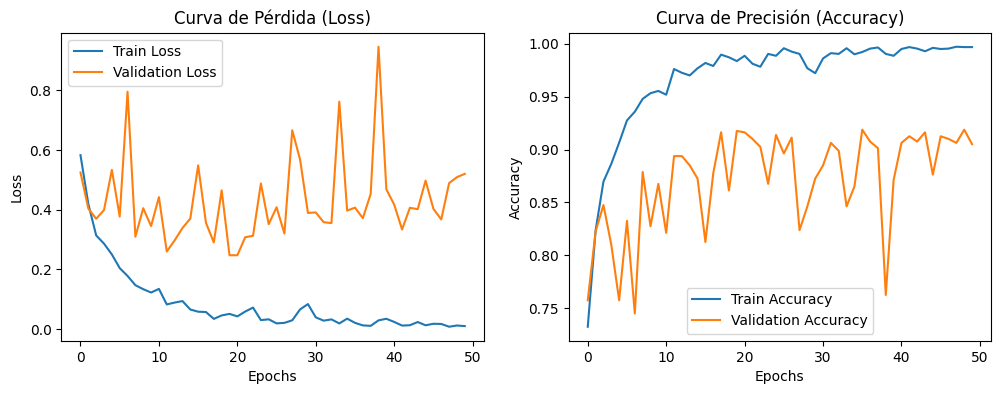

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step


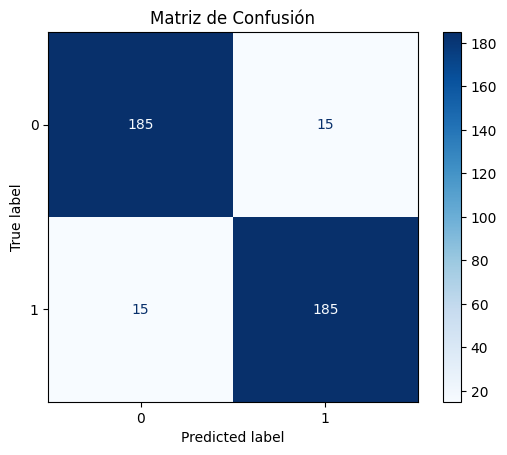

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


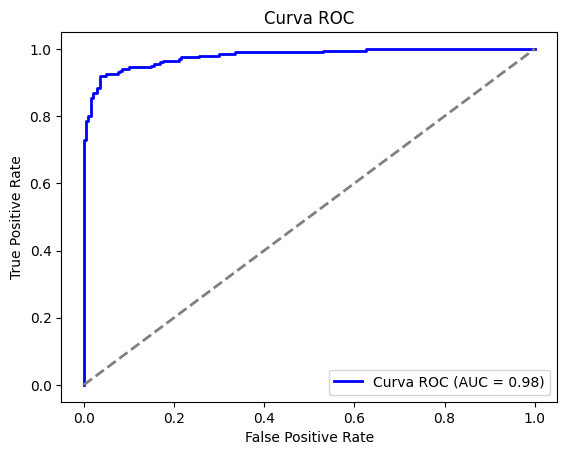

88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9930 - loss: 0.0214
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.8950 - loss: 0.5516
Train Loss: 0.0199, Train Accuracy: 0.9929
Validation Loss: 0.4067, Validation Accuracy: 0.9187

Clasificación detallada (Precision, Recall, F1-score):

              precision    recall  f1-score   support

    Sin Humo       0.93      0.93      0.93       200
    Con Humo       0.93      0.93      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
AUC Score: 0.9792


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, ConfusionMatrixDisplay, roc_auc_score
import numpy as np
import seaborn as sns

# Cargar el mejor modelo
best_model = keras.models.load_model('best_model_GS.keras')

# 1. Estructura de la red
best_model.summary()

# Guardar la estructura del modelo
with open("model_structure.txt", "w") as f:
    best_model.summary(print_fn=lambda x: f.write(x + '\n'))

# 2. Curva de Loss y Accuracy para entrenamiento y validación
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("loss_accuracy_curves.png")
plt.show()

# 3. Matriz de confusión
y_pred = (best_model.predict(test_videos) >= 0.5).astype(int)
cm = confusion_matrix(test_labels, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.savefig("confusion_matrix.png")
plt.show()

# 4. Curva ROC/AUC
fpr, tpr, _ = roc_curve(test_labels, best_model.predict(test_videos))
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()

# 5. Métricas finales del mejor modelo
train_loss, train_acc = best_model.evaluate(train_videos, train_labels)
val_loss, val_acc = best_model.evaluate(valid_videos, valid_labels)
print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

# Precision, Recall, F1-Score
print("\nClasificación detallada (Precision, Recall, F1-score):\n")
print(classification_report(test_labels, y_pred, target_names=['Sin Humo', 'Con Humo']))

# Opcional: Calcular y mostrar AUC
roc_auc_value = roc_auc_score(test_labels, best_model.predict(test_videos))
print(f"AUC Score: {roc_auc_value:.4f}")


In [ ]:
best_model = keras.models.load_model('best_model_GS.keras')

test_loss, test_acc = best_model.evaluate(test_videos, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9211 - loss: 0.3475
Test accuracy: 92.50%
